## 1. Install Required Libraries

In [1]:
# Uncomment if required:
# !pip install -q pandas numpy matplotlib seaborn nltk scikit-learn transformers torch wordcloud

import os
import re
import warnings
import urllib.request
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from transformers import pipeline

from wordcloud import WordCloud

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Collect / Load Real Product Feedback Data


In [2]:
DATA_PATH = "/content/fine_food_reviews_1k.csv"
DATA_URL = "https://raw.githubusercontent.com/openai/openai-cookbook/main/examples/data/fine_food_reviews_1k.csv"

# Download the real dataset automatically if it is not in the notebook folder.
if not os.path.exists(DATA_PATH):
    print("Local dataset not found. Downloading the real Amazon Fine Food Reviews dataset...")
    try:
        urllib.request.urlretrieve(DATA_URL, DATA_PATH)
        print("Dataset downloaded successfully.")
    except Exception as e:
        raise RuntimeError(
            "Could not download the dataset. Download it manually from the raw CSV link "
            "shown above and place fine_food_reviews_1k.csv beside this notebook."
        ) from e

raw_df = pd.read_csv(DATA_PATH)

# Validate the expected columns.
required_cols = {"ProductId", "Score", "Summary", "Text"}
missing = required_cols - set(raw_df.columns)
if missing:
    raise ValueError(f"Dataset is missing expected columns: {missing}")

# Build the feedback field from review summary + review body.
raw_df["Summary"] = raw_df["Summary"].fillna("").astype(str)
raw_df["Text"] = raw_df["Text"].fillna("").astype(str)
raw_df["feedback"] = (
    raw_df["Summary"].str.strip() + ". " + raw_df["Text"].str.strip()
).str.strip()

df = raw_df[["ProductId", "Score", "Summary", "Text", "feedback"]].copy()
df = df[df["feedback"].str.len() > 0].drop_duplicates(subset=["feedback"]).reset_index(drop=True)

print("Dataset source: Amazon Fine Food Reviews")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Dataset source: Amazon Fine Food Reviews
Dataset shape: (762, 5)
Columns: ['ProductId', 'Score', 'Summary', 'Text', 'feedback']


,ProductId,Score,Summary,Text,feedback
0,B003XPF9BO,5,where does one start...and stop... with a tre...,Wanted to save some to bring to my Chicago fam...,where does one start...and stop... with a tre...
1,B003JK537S,1,Arrived in pieces,"Not pleased at all. When I opened the box, mos...",Arrived in pieces. Not pleased at all. When I ...
2,B000JMBE7M,4,"It isn't blanc mange, but isn't bad . . .",I'm not sure that custard is really custard wi...,"It isn't blanc mange, but isn't bad . . .. I'm..."
3,B004AHGBX4,3,These also have SALT and it's not sea salt.,I like the fact that you can see what you're g...,These also have SALT and it's not sea salt.. I...
4,B001BORBHO,5,Happy with the product,My dog was suffering with itchy skin. He had ...,Happy with the product. My dog was suffering w...


## 4. Exploratory Data Analysis

Number of real customer reviews: 762

Missing values:


,0
ProductId,0
Score,0
Summary,0
Text,0
feedback,0



Star-rating distribution:


,Number of Reviews
Score,
1,65
2,39
3,55
4,109
5,494


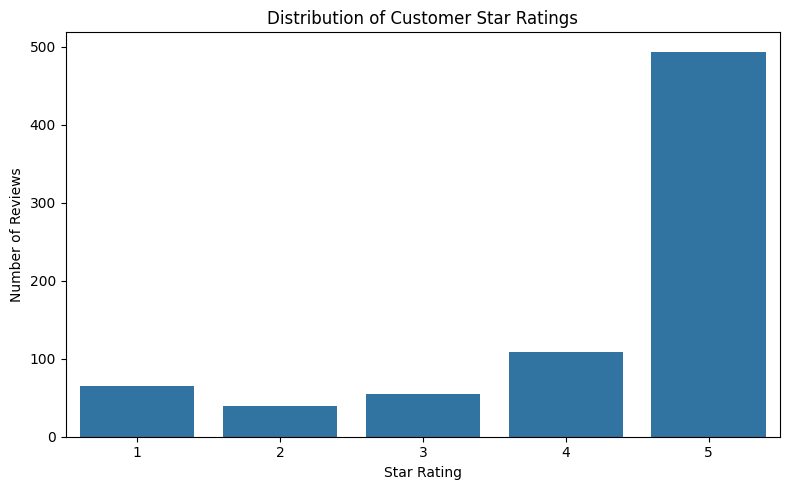


Feedback length statistics:


,word_count
count,762.000000
mean,74.208661
std,59.104996
min,21.000000
25%,34.000000
50%,56.000000
75%,94.000000
max,542.000000


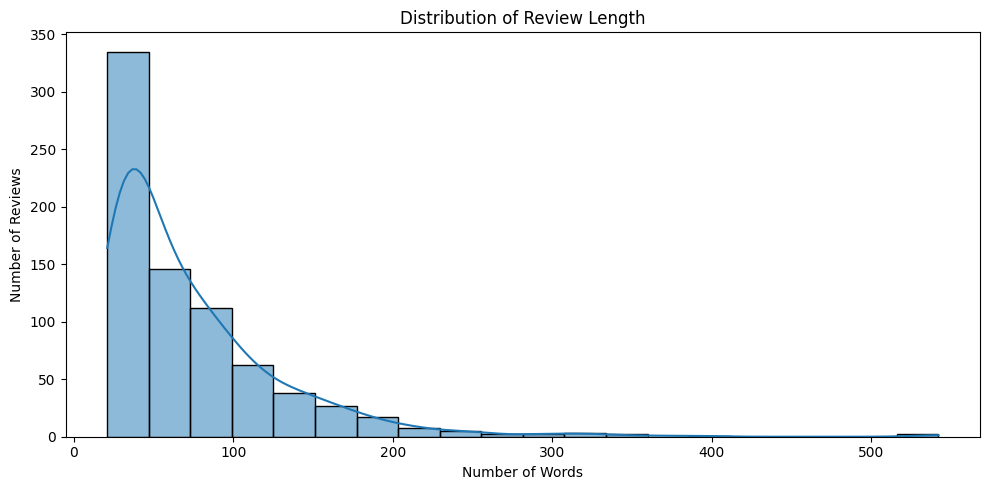

In [3]:
print("Number of real customer reviews:", len(df))
print("\nMissing values:")
display(df.isna().sum())

print("\nStar-rating distribution:")
rating_counts = df["Score"].value_counts().sort_index()
display(rating_counts.rename("Number of Reviews"))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Score")
plt.title("Distribution of Customer Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

df["word_count"] = df["feedback"].str.findall(r"\b\w+\b").str.len()

print("\nFeedback length statistics:")
display(df["word_count"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=20, kde=True)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


## 5. Text Preprocessing


In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(tokens)

df["clean_feedback"] = df["feedback"].apply(preprocess_text)

display(df[["feedback", "clean_feedback"]].head(10))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


,feedback,clean_feedback
0,where does one start...and stop... with a tre...,one start stop treat like wanted save bring ch...
1,Arrived in pieces. Not pleased at all. When I ...,arrived piece pleased opened box ring broken p...
2,"It isn't blanc mange, but isn't bad . . .. I'm...",blanc mange bad sure custard really custard wi...
3,These also have SALT and it's not sea salt.. I...,also salt sea salt like fact see getting bone ...
4,Happy with the product. My dog was suffering w...,happy product dog suffering itchy skin eating ...
5,Good Sauce. This is a good all purpose sauce. ...,good sauce good purpose sauce good flavor heat...
6,Blackcat. Great coffee! Love all Green Mounta...,blackcat great coffee love green mountain coff...
7,Excellent product. After scouring every store ...,excellent product scouring every store town or...
8,Bulk k-Cups. This is the best way to buy coffe...,bulk cup best way buy coffee office least expe...
9,"It's Okay. Next time, I will buy Gevalia Irish...",okay next time buy gevalia irish cream decaf c...


## 6. Transformer-Based Sentiment Analysis


In [8]:
MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

try:
    sentiment_model = pipeline(
        "sentiment-analysis",
        model=MODEL_NAME,
        tokenizer=MODEL_NAME
    )
    print("Transformer sentiment model loaded.")
except Exception as e:
    print("Transformer model could not be loaded.")
    print("Error:", e)
    sentiment_model = None


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Transformer sentiment model loaded.


## 7. Predict Sentiment for All Feedback

In [9]:
def get_sentiments(texts, batch_size=16):
    if sentiment_model is None:
        # Fallback only if the transformer model cannot be downloaded.
        positive_words = {"excellent","great","good","love","easy","impressive","satisfied","premium","fast","durable"}
        negative_words = {"terrible","bad","poor","cheap","expensive","damaged","confusing","difficult","slow","disappointing","buggy","late","hot"}

        results = []
        for text in texts:
            tokens = set(preprocess_text(text).split())
            p = len(tokens & positive_words)
            n = len(tokens & negative_words)
            if p > n:
                results.append({"label":"POSITIVE", "score":0.60})
            elif n > p:
                results.append({"label":"NEGATIVE", "score":0.60})
            else:
                results.append({"label":"NEUTRAL", "score":0.50})
        return results

    return sentiment_model(
        list(texts),
        batch_size=batch_size,
        truncation=True,
        max_length=256
    )

sentiment_results = get_sentiments(df["feedback"])

df["sentiment"] = [r["label"].title() for r in sentiment_results]
df["sentiment_score"] = [round(float(r["score"]), 4) for r in sentiment_results]

display(df[["feedback", "sentiment", "sentiment_score"]].head(10))


,feedback,sentiment,sentiment_score
0,where does one start...and stop... with a tre...,Positive,0.9986
1,Arrived in pieces. Not pleased at all. When I ...,Negative,0.9998
2,"It isn't blanc mange, but isn't bad . . .. I'm...",Positive,0.9496
3,These also have SALT and it's not sea salt.. I...,Negative,0.9935
4,Happy with the product. My dog was suffering w...,Positive,0.9800
5,Good Sauce. This is a good all purpose sauce. ...,Positive,0.9952
6,Blackcat. Great coffee! Love all Green Mounta...,Positive,0.9999
7,Excellent product. After scouring every store ...,Positive,0.9306
8,Bulk k-Cups. This is the best way to buy coffe...,Negative,0.9096
9,"It's Okay. Next time, I will buy Gevalia Irish...",Negative,0.9525


## 8. Sentiment Distribution

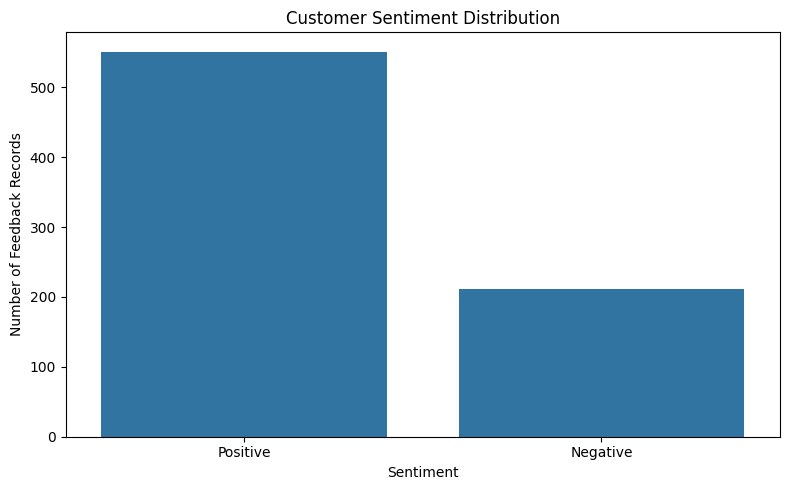

Sentiment percentages:


,Percentage
sentiment,
Positive,72.31
Negative,27.69


In [10]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback Records")
plt.tight_layout()
plt.show()

sentiment_percent = (sentiment_counts / len(df) * 100).round(2)
print("Sentiment percentages:")
display(sentiment_percent.rename("Percentage"))


## 9. Rating vs. NLP Sentiment


sentiment,Negative,Positive
Score,,
1,59,6
2,35,4
3,35,20
4,25,84
5,57,437


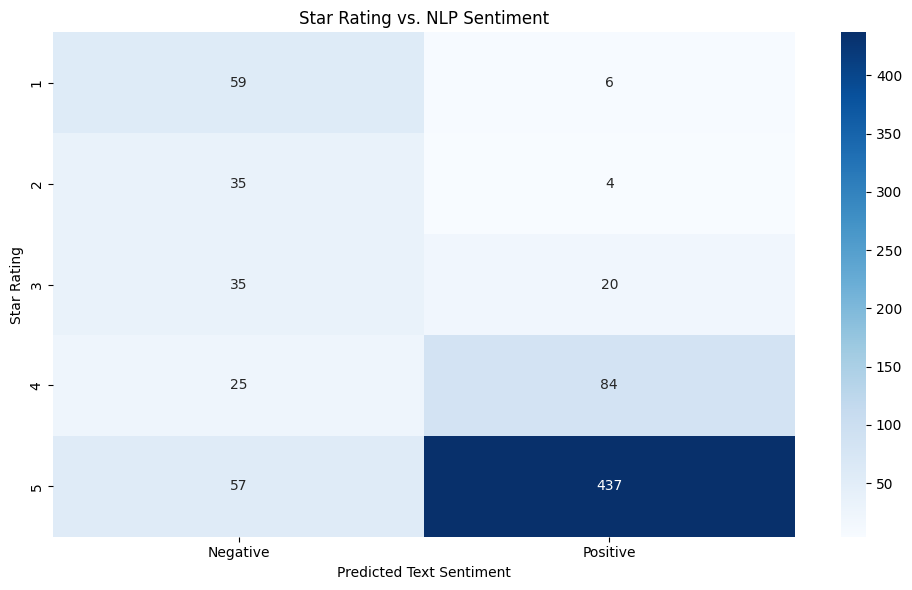

In [11]:
rating_sentiment = pd.crosstab(df["Score"], df["sentiment"])
display(rating_sentiment)

plt.figure(figsize=(10, 6))
sns.heatmap(rating_sentiment, annot=True, fmt="d", cmap="Blues")
plt.title("Star Rating vs. NLP Sentiment")
plt.xlabel("Predicted Text Sentiment")
plt.ylabel("Star Rating")
plt.tight_layout()
plt.show()


## 10. Word Frequency Analysis

,word,frequency
0,like,332
1,good,317
2,great,315
3,coffee,265
4,taste,257
5,product,251
6,love,244
7,flavor,233
8,one,208
9,tea,175


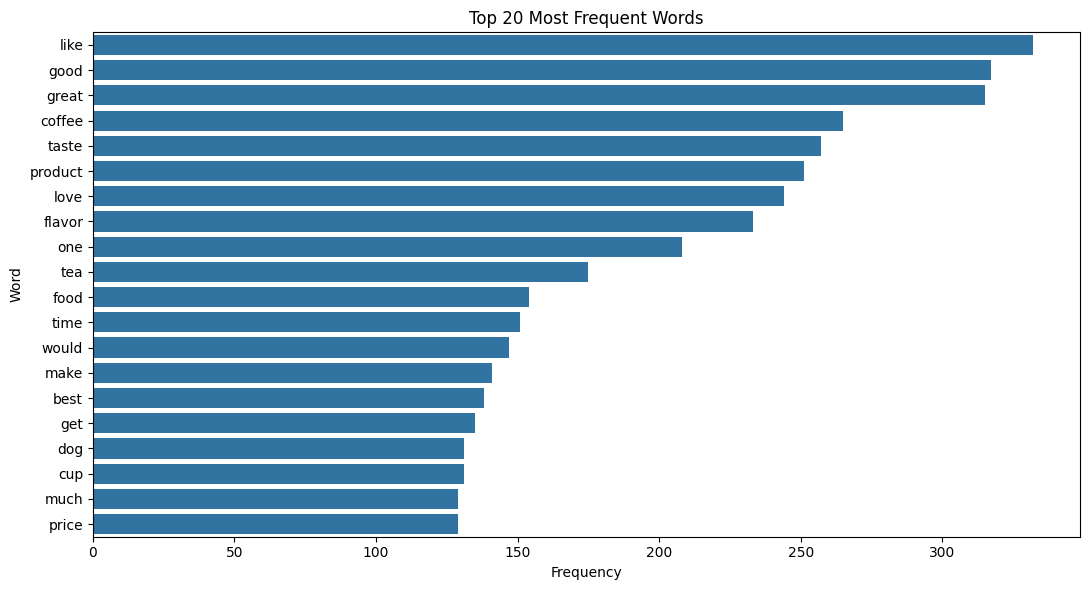

In [12]:
all_words = " ".join(df["clean_feedback"]).split()
word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "frequency"]
)

display(common_words)

plt.figure(figsize=(11, 6))
sns.barplot(data=common_words, x="frequency", y="word")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


## 11. TF-IDF Keyword Extraction

,term,tfidf_score
13,great,0.116116
12,good,0.113511
14,like,0.107155
20,product,0.100051
24,taste,0.096443
16,love,0.092471
5,coffee,0.087382
10,flavor,0.084267
26,time,0.061394
2,best,0.060359


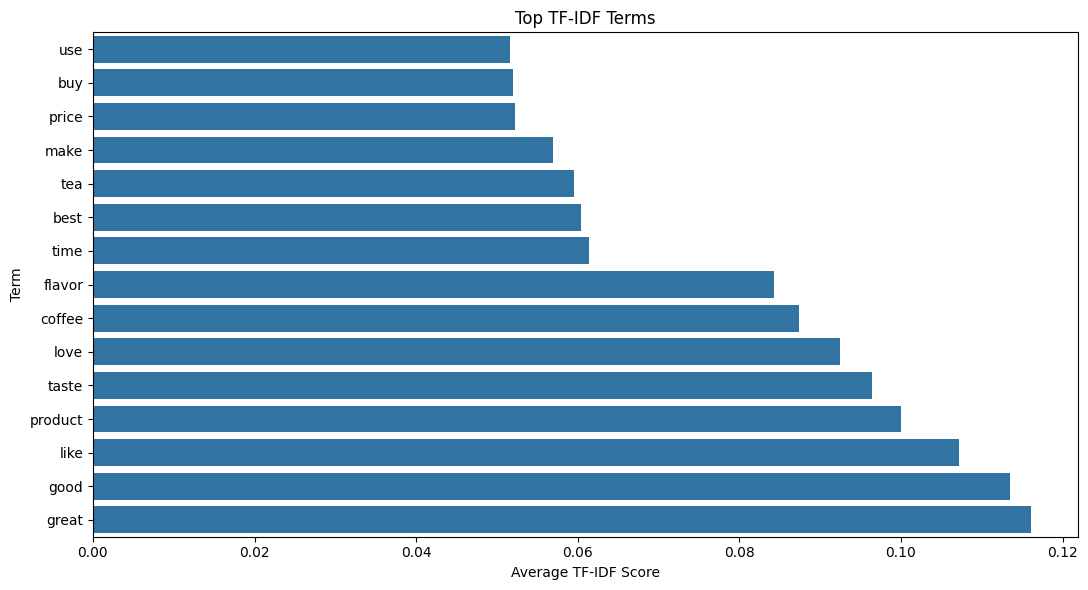

In [13]:
vectorizer = TfidfVectorizer(
    max_features=30,
    ngram_range=(1, 2),
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(df["clean_feedback"])
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_terms = pd.DataFrame({
    "term": vectorizer.get_feature_names_out(),
    "tfidf_score": tfidf_scores
}).sort_values("tfidf_score", ascending=False)

display(tfidf_terms.head(20))

plt.figure(figsize=(11, 6))
top_tfidf = tfidf_terms.head(15).sort_values("tfidf_score")
sns.barplot(data=top_tfidf, x="tfidf_score", y="term")
plt.title("Top TF-IDF Terms")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


## 12. Product Aspect Identification

In [14]:
aspect_keywords = {
    "Taste & Flavor": [
        "taste", "flavor", "flavour", "tasty", "delicious", "sweet",
        "salty", "bitter", "spicy", "bland", "fresh"
    ],
    "Product Quality": [
        "quality", "product", "ingredient", "ingredients", "organic",
        "natural", "authentic", "freshness"
    ],
    "Price & Value": [
        "price", "pricing", "expensive", "cheap", "cost", "value",
        "money", "worth", "affordable"
    ],
    "Packaging": [
        "packaging", "package", "box", "packed", "packing", "bag",
        "container", "seal", "sealed", "damaged", "broken"
    ],
    "Texture & Consistency": [
        "texture", "crunchy", "crispy", "soft", "hard", "smooth",
        "thick", "thin", "consistency"
    ],
    "Quantity & Size": [
        "quantity", "size", "small", "large", "amount", "portion",
        "serving", "weight"
    ],
    "Ingredients & Health": [
        "ingredient", "ingredients", "sugar", "salt", "calorie",
        "healthy", "health", "diet", "gluten", "organic"
    ],
    "Delivery": [
        "delivery", "delivered", "shipping", "arrived", "arrival",
        "late", "delivery"
    ],
    "Customer Service": [
        "support", "customer", "service", "seller", "refund",
        "replacement", "response", "help"
    ]
}

def detect_aspects(text):
    text_clean = preprocess_text(text)
    found = []
    for aspect, keywords in aspect_keywords.items():
        if any(
            re.search(r"\b" + re.escape(keyword) + r"\b", text_clean)
            for keyword in keywords
        ):
            found.append(aspect)
    return found if found else ["General"]

df["aspects"] = df["feedback"].apply(detect_aspects)
display(df[["feedback", "aspects"]].head(10))


,feedback,aspects
0,where does one start...and stop... with a tre...,[Packaging]
1,Arrived in pieces. Not pleased at all. When I ...,"[Price & Value, Packaging, Delivery]"
2,"It isn't blanc mange, but isn't bad . . .. I'm...","[Taste & Flavor, Price & Value, Texture & Cons..."
3,These also have SALT and it's not sea salt.. I...,"[Taste & Flavor, Product Quality, Ingredients ..."
4,Happy with the product. My dog was suffering w...,[Product Quality]
5,Good Sauce. This is a good all purpose sauce. ...,"[Taste & Flavor, Product Quality]"
6,Blackcat. Great coffee! Love all Green Mounta...,[Taste & Flavor]
7,Excellent product. After scouring every store ...,"[Taste & Flavor, Product Quality, Packaging, T..."
8,Bulk k-Cups. This is the best way to buy coffe...,"[Taste & Flavor, Price & Value]"
9,"It's Okay. Next time, I will buy Gevalia Irish...",[Ingredients & Health]


## 13. Aspect Frequency Analysis

,aspect,count
0,Taste & Flavor,399
1,Product Quality,247
2,Price & Value,190
3,Ingredients & Health,186
4,Packaging,171
5,Quantity & Size,102
6,Texture & Consistency,100
7,General,96
8,Delivery,61
9,Customer Service,59


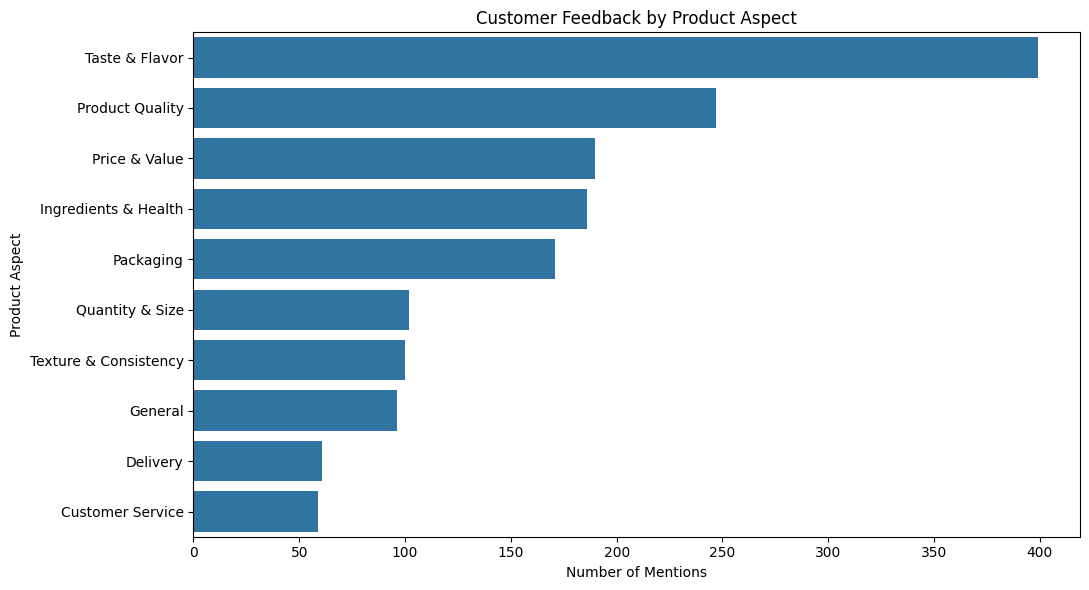

In [15]:
aspect_rows = []
for _, row in df.iterrows():
    for aspect in row["aspects"]:
        aspect_rows.append({
            "aspect": aspect,
            "sentiment": row["sentiment"],
            "score": row["sentiment_score"],
            "feedback": row["feedback"]
        })

aspect_df = pd.DataFrame(aspect_rows)

aspect_counts = aspect_df["aspect"].value_counts().reset_index()
aspect_counts.columns = ["aspect", "count"]

display(aspect_counts)

plt.figure(figsize=(11, 6))
sns.barplot(data=aspect_counts, x="count", y="aspect")
plt.title("Customer Feedback by Product Aspect")
plt.xlabel("Number of Mentions")
plt.ylabel("Product Aspect")
plt.tight_layout()
plt.show()


## 14. Aspect vs. Sentiment

sentiment,Positive,Negative,Neutral
aspect,,,
Customer Service,35,24,0
Delivery,36,25,0
General,72,24,0
Ingredients & Health,135,51,0
Packaging,107,64,0
Price & Value,126,64,0
Product Quality,163,84,0
Quantity & Size,69,33,0
Taste & Flavor,306,93,0


<Figure size 1200x700 with 0 Axes>

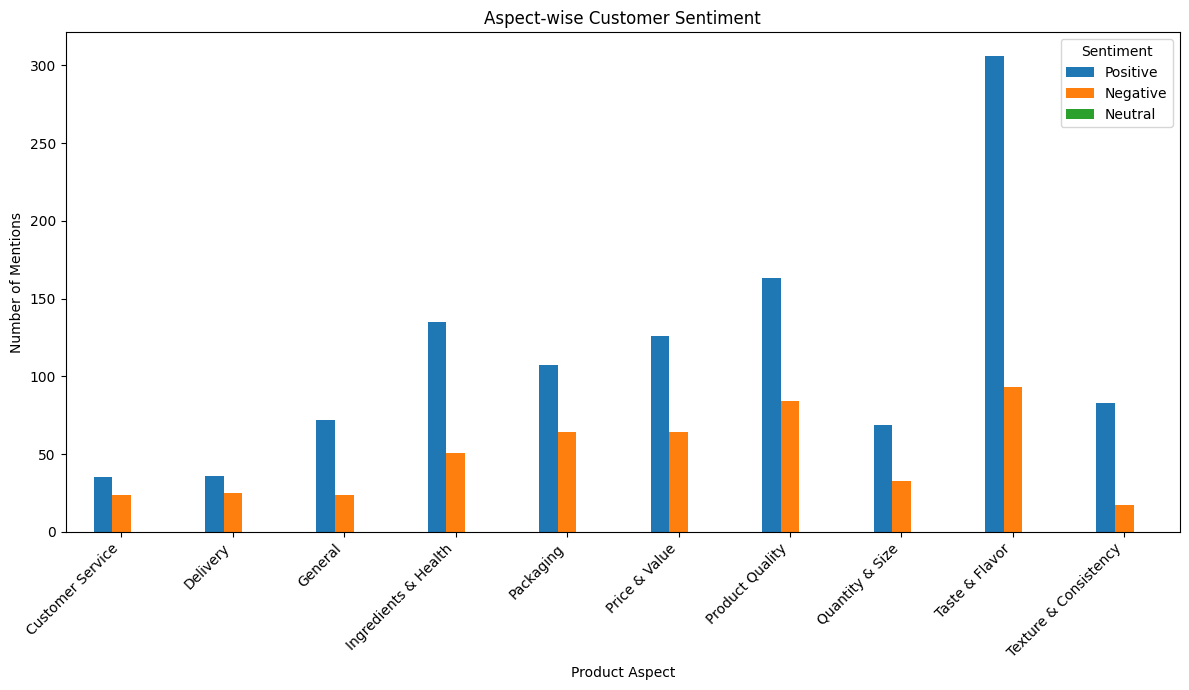

In [16]:
aspect_sentiment = pd.crosstab(
    aspect_df["aspect"],
    aspect_df["sentiment"]
)

for col in ["Positive", "Negative", "Neutral"]:
    if col not in aspect_sentiment.columns:
        aspect_sentiment[col] = 0

aspect_sentiment = aspect_sentiment[["Positive", "Negative", "Neutral"]]

display(aspect_sentiment)

plt.figure(figsize=(12, 7))
aspect_sentiment.plot(kind="bar", figsize=(12, 7))
plt.title("Aspect-wise Customer Sentiment")
plt.xlabel("Product Aspect")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


## 15. Identify Product Improvement Areas

In [17]:
aspect_summary = aspect_df.groupby("aspect").agg(
    total_mentions=("aspect", "size"),
    negative_mentions=("sentiment", lambda x: (x == "Negative").sum()),
    positive_mentions=("sentiment", lambda x: (x == "Positive").sum()),
    neutral_mentions=("sentiment", lambda x: (x == "Neutral").sum())
).reset_index()

aspect_summary["negative_rate"] = (
    aspect_summary["negative_mentions"] /
    aspect_summary["total_mentions"] * 100
).round(2)

aspect_summary["positive_rate"] = (
    aspect_summary["positive_mentions"] /
    aspect_summary["total_mentions"] * 100
).round(2)

# Rank aspects using a combination of negative volume and negative rate.
aspect_summary["priority_score"] = (
    aspect_summary["negative_mentions"] * 0.7 +
    aspect_summary["negative_rate"] * 0.3
).round(2)

improvement_areas = aspect_summary[
    aspect_summary["negative_mentions"] > 0
].sort_values(
    ["priority_score", "negative_mentions"],
    ascending=False
)

display(improvement_areas)


,aspect,total_mentions,negative_mentions,positive_mentions,neutral_mentions,negative_rate,positive_rate,priority_score
8,Taste & Flavor,399,93,306,0,23.31,76.69,72.09
6,Product Quality,247,84,163,0,34.01,65.99,69.00
4,Packaging,171,64,107,0,37.43,62.57,56.03
5,Price & Value,190,64,126,0,33.68,66.32,54.90
3,Ingredients & Health,186,51,135,0,27.42,72.58,43.93
7,Quantity & Size,102,33,69,0,32.35,67.65,32.80
1,Delivery,61,25,36,0,40.98,59.02,29.79
0,Customer Service,59,24,35,0,40.68,59.32,29.00
2,General,96,24,72,0,25.00,75.00,24.30
9,Texture & Consistency,100,17,83,0,17.00,83.00,17.00


## 16. Improvement Area Visualization

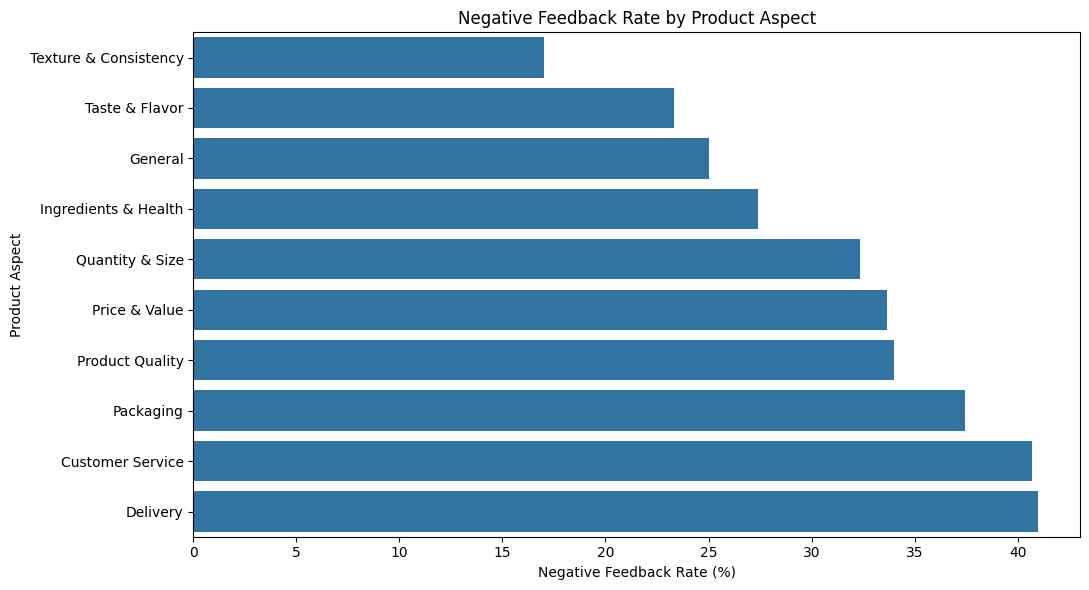

In [18]:
plot_df = improvement_areas.head(10).sort_values("negative_rate")

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="negative_rate", y="aspect")
plt.title("Negative Feedback Rate by Product Aspect")
plt.xlabel("Negative Feedback Rate (%)")
plt.ylabel("Product Aspect")
plt.tight_layout()
plt.show()


## 17. Word Cloud for Negative Feedback

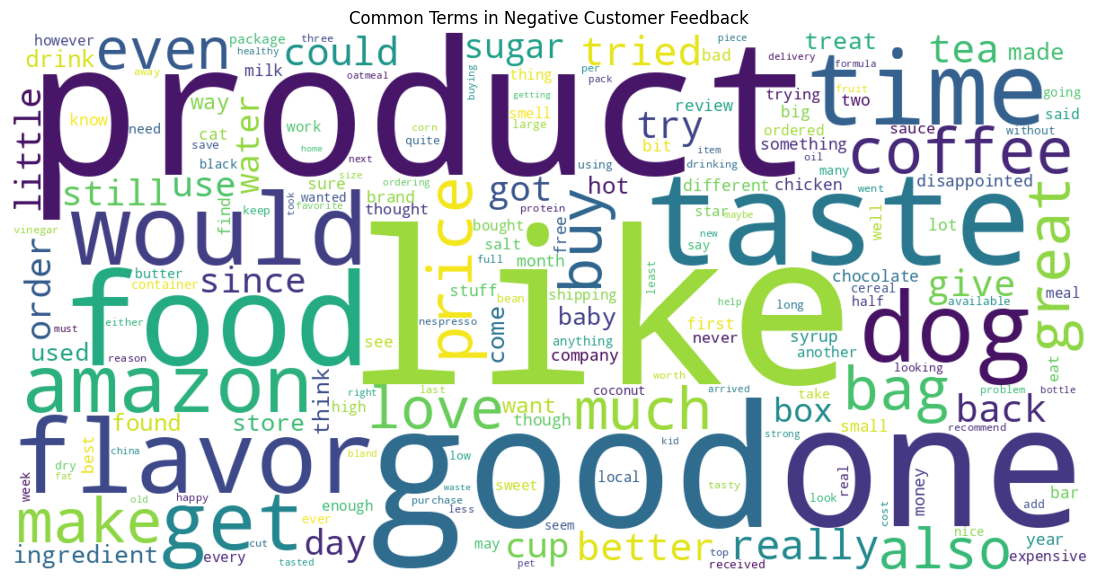

In [19]:
negative_text = " ".join(
    df.loc[df["sentiment"] == "Negative", "clean_feedback"]
)

if negative_text.strip():
    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stop_words,
        collocations=False
    ).generate(negative_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Common Terms in Negative Customer Feedback")
    plt.show()
else:
    print("No negative feedback was detected.")


## 18. Extract Representative Negative Feedback

This section provides concrete examples behind the statistical results, which makes the business recommendations easier to explain.

In [20]:
for aspect in improvement_areas.head(5)["aspect"]:
    examples = aspect_df[
        (aspect_df["aspect"] == aspect) &
        (aspect_df["sentiment"] == "Negative")
    ]["feedback"].head(3).tolist()

    print(f"\n### {aspect}")
    if examples:
        for i, example in enumerate(examples, 1):
            print(f"{i}. {example}")
    else:
        print("No negative examples available.")



### Taste & Flavor
1. These also have SALT and it's not sea salt.. I like the fact that you can see what you're getting and that there are no bones or dark meat.  There are 7 nice big chunks in every jar.<br /><br />These taste like tuna in a can but, because they're preserved in glass, you don't have to worry about either aluminum or BPA; BUT ... they are not just tuna and spring water.<br /><br />There is salt in there, too, and it's not healthy sea salt, it's toxic table salt.<br /><br />I am trying to contact Tonnino to confirm that.  I might be wrong because the label states that the ingredients are "tuna fish" but the sticker on the top clarifies that it is the smaller (healthier) yellowfin, so the "salt" listed in the ingredients might be sea salt but, if it was, why don't they say so?<br /><br />Without confirmation, I will continue to look for a salt-free olive-oil free tuna preserved in glass.<br /><br />If you know of one, please contact me!
2. Bulk k-Cups. This is the best

## 19. Automated Business Insight Generation

In [21]:
def generate_insights(summary):
    insights = []

    for _, row in summary.sort_values(
        ["priority_score", "negative_mentions"],
        ascending=False
    ).iterrows():
        if row["negative_mentions"] > 0:
            aspect = row["aspect"]
            neg = int(row["negative_mentions"])
            total = int(row["total_mentions"])
            rate = row["negative_rate"]

            if rate >= 60:
                action = "requires urgent investigation and corrective action"
            elif rate >= 40:
                action = "should be prioritized for product improvement"
            else:
                action = "should be monitored and improved where practical"

            insights.append(
                f"{aspect}: {neg} of {total} mentions were negative "
                f"({rate:.1f}%). This aspect {action}."
            )

    return insights

business_insights = generate_insights(aspect_summary)

print("BUSINESS INSIGHTS")
print("=" * 70)

if business_insights:
    for i, insight in enumerate(business_insights, 1):
        print(f"{i}. {insight}")
else:
    print("No significant negative product aspects were identified.")


BUSINESS INSIGHTS
1. Taste & Flavor: 93 of 399 mentions were negative (23.3%). This aspect should be monitored and improved where practical.
2. Product Quality: 84 of 247 mentions were negative (34.0%). This aspect should be monitored and improved where practical.
3. Packaging: 64 of 171 mentions were negative (37.4%). This aspect should be monitored and improved where practical.
4. Price & Value: 64 of 190 mentions were negative (33.7%). This aspect should be monitored and improved where practical.
5. Ingredients & Health: 51 of 186 mentions were negative (27.4%). This aspect should be monitored and improved where practical.
6. Quantity & Size: 33 of 102 mentions were negative (32.4%). This aspect should be monitored and improved where practical.
7. Delivery: 25 of 61 mentions were negative (41.0%). This aspect should be prioritized for product improvement.
8. Customer Service: 24 of 59 mentions were negative (40.7%). This aspect should be prioritized for product improvement.
9. Gener

## 20. Executive Summary

In [22]:
total_feedback = len(df)
positive_pct = (df["sentiment"].eq("Positive").mean() * 100)
negative_pct = (df["sentiment"].eq("Negative").mean() * 100)
neutral_pct = (df["sentiment"].eq("Neutral").mean() * 100)

top_negative_aspects = improvement_areas.head(5)["aspect"].tolist()

print("=" * 75)
print("PRODUCT FEEDBACK ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 75)
print(f"Total feedback analyzed : {total_feedback}")
print(f"Positive feedback       : {positive_pct:.2f}%")
print(f"Negative feedback       : {negative_pct:.2f}%")
print(f"Neutral feedback        : {neutral_pct:.2f}%")

if top_negative_aspects:
    print("\nPriority improvement areas:")
    for i, aspect in enumerate(top_negative_aspects, 1):
        print(f"  {i}. {aspect}")

print("\nRecommended management actions:")
if top_negative_aspects:
    print("  • Investigate the highest-priority negative aspects.")
    print("  • Review recurring customer complaints for root causes.")
    print("  • Prioritize improvements based on negative volume and rate.")
    print("  • Track future feedback to measure whether sentiment improves.")
else:
    print("  • Continue monitoring customer feedback.")
    print("  • Maintain the current product strengths.")
print("=" * 75)


PRODUCT FEEDBACK ANALYSIS — EXECUTIVE SUMMARY
Total feedback analyzed : 762
Positive feedback       : 72.31%
Negative feedback       : 27.69%
Neutral feedback        : 0.00%

Priority improvement areas:
  1. Taste & Flavor
  2. Product Quality
  3. Packaging
  4. Price & Value
  5. Ingredients & Health

Recommended management actions:
  • Investigate the highest-priority negative aspects.
  • Review recurring customer complaints for root causes.
  • Prioritize improvements based on negative volume and rate.
  • Track future feedback to measure whether sentiment improves.


## 21. Final Analytical Dataset

The resulting dataset contains the original feedback, cleaned text, sentiment prediction, confidence score, and detected product aspects.

In [23]:
final_columns = [
    "feedback",
    "clean_feedback",
    "sentiment",
    "sentiment_score",
    "aspects"
]

final_df = df[final_columns].copy()

display(final_df.head(20))

# Optional: save the analyzed results
final_df.to_csv("product_feedback_analysis_results.csv", index=False)
print("Saved: product_feedback_analysis_results.csv")


,feedback,clean_feedback,sentiment,sentiment_score,aspects
0,where does one start...and stop... with a tre...,one start stop treat like wanted save bring ch...,Positive,0.9986,[Packaging]
1,Arrived in pieces. Not pleased at all. When I ...,arrived piece pleased opened box ring broken p...,Negative,0.9998,"[Price & Value, Packaging, Delivery]"
2,"It isn't blanc mange, but isn't bad . . .. I'm...",blanc mange bad sure custard really custard wi...,Positive,0.9496,"[Taste & Flavor, Price & Value, Texture & Cons..."
3,These also have SALT and it's not sea salt.. I...,also salt sea salt like fact see getting bone ...,Negative,0.9935,"[Taste & Flavor, Product Quality, Ingredients ..."
4,Happy with the product. My dog was suffering w...,happy product dog suffering itchy skin eating ...,Positive,0.9800,[Product Quality]
5,Good Sauce. This is a good all purpose sauce. ...,good sauce good purpose sauce good flavor heat...,Positive,0.9952,"[Taste & Flavor, Product Quality]"
6,Blackcat. Great coffee! Love all Green Mounta...,blackcat great coffee love green mountain coff...,Positive,0.9999,[Taste & Flavor]
7,Excellent product. After scouring every store ...,excellent product scouring every store town or...,Positive,0.9306,"[Taste & Flavor, Product Quality, Packaging, T..."
8,Bulk k-Cups. This is the best way to buy coffe...,bulk cup best way buy coffee office least expe...,Negative,0.9096,"[Taste & Flavor, Price & Value]"
9,"It's Okay. Next time, I will buy Gevalia Irish...",okay next time buy gevalia irish cream decaf c...,Negative,0.9525,[Ingredients & Health]


Saved: product_feedback_analysis_results.csv
